In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from benchmarking.constants import TOOL_NAMES, TOOL_COLORS, DATASET_DESCRIPTORS
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Patch

In [2]:
base_dir_public = "../data/public_dataset"
public_datasets = [
    "MSV000090327",
    "MSV000091642",
    "MSV000095813",
    "MSV000097967",
    "MSV000097015",
    "MSV000096291",
    "MSV000096189",
    "ST002402",
    "MSV000084402",
    "MTBLS12332",
]

base_dir_internal = "../data/groundtruth_dataset"
internal_datasets = [
    "MSV000098263",
    "NIST_SRM",
    "plant_spikein",
]

In [3]:
input_dataset_directories = []

for dataset in public_datasets:
    input_dataset_directories.append(os.path.join(base_dir_public, dataset))

for dataset in internal_datasets:
    input_dataset_directories.append(os.path.join(base_dir_internal, dataset))

len(input_dataset_directories)

13

In [4]:
similarity_threshold = 0.7
annotation_subfolder = "annotated_spectral_entropy"

In [5]:
# Merge all feature tables
merged_feature_tables = []

for path_to_dataset in input_dataset_directories:
    annotation_path = os.path.join(path_to_dataset, annotation_subfolder)

    # Define paths and tools
    annotation_paths = []
    harmonized_paths = []
    tools = []
    for file in os.listdir(annotation_path):
        annotation_paths.append(os.path.join(annotation_path, file))
        harmonized_filepath = os.path.join(annotation_path, file).replace(
            annotation_subfolder, "harmonized"
        )
        harmonized_paths.append(harmonized_filepath)
        if "mzmine" in file.lower():
            tool = "mzmine"
        elif "msdial" in file.lower():
            tool = "msdial"
        elif "metaboscape" in file.lower():
            tool = "metaboscape"
        else:
            raise ValueError(f"Unknown tool type in file name: {file}")
        tools.append(tool)

    for annotated_path, harmonized_path, tool_type in zip(
        annotation_paths, harmonized_paths, tools
    ):
        if not os.path.exists(annotated_path) or not os.path.exists(harmonized_path):
            continue

        annotations = pd.read_parquet(annotated_path)
        feature_table = pd.read_parquet(harmonized_path)

        annotations["FEATURE_ID"] = annotations["FEATURE_ID"].astype(
            feature_table["FEATURE_ID"].dtype
        )
        feature_table = feature_table.merge(annotations, on="FEATURE_ID", how="left")
        dataset = annotated_path.split("/")[-1].split(f"_{tool_type}")[0]

        feature_table["tool"] = tool_type
        feature_table["dataset"] = dataset

        merged_feature_tables.append(feature_table)

all_tables = pd.concat(merged_feature_tables, ignore_index=True)
all_tables.head(3)

,FEATURE_ID,M/Z,RT,ION_MOBILITY,CCS,ADDUCT,MS/MS_ASSIGNED,MS/MS_MZS,MS/MS_INTENSITIES,QC_RE1_1_1641,...,SAMPLE_ESN-0041856_colchicine_50ng_C18_POS_5ul_P1-F3_1_701 Peak height,SAMPLE_ESN-0042027_catharanthine_100ng_C18_POS_10ul_P1-C6_1_994 Peak height,SAMPLE_ESN-0042027_catharanthine_200ng_C18_POS_20ul_P1-C6_1_1019 Peak height,SAMPLE_ESN-0042027_catharanthine_50ng_C18_POS_5ul_P1-E8_1_695 Peak height,MSBLANK_20%MeOH_C18_POS_10ul_P1-A1_1_1010,MSBLANK_20%MeOH_C18_POS_10ul_P1-A1_1_1012,MSBLANK_20%MeOH_C18_POS_10ul_P1-A1_1_1022,MSBLANK_20%MeOH_C18_POS_10ul_P1-A1_1_987,MSBLANK_20%MeOH_C18_POS_10ul_P1-A1_1_997,MSBLANK_20%MeOH_C18_POS_10ul_P1-A1_1_999
0,1,31.62816,8.188,0.737,202.567,,False,[],[],3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3,60.05581,8.375,0.869,210.783,,False,[],[],54.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,5,62.28127,8.027,0.803,193.520,,False,[],[],111.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
all_tables["tool"].value_counts()

tool
mzmine         749200
msdial         321979
metaboscape    268259
Name: count, dtype: int64

In [7]:
all_tables["dataset"].value_counts()

dataset
MSV000098263     280650
MSV000097967     254891
MTBLS12332       149243
ST002402         133252
NIST_SRM         123067
plant_spikein    115458
MSV000090327     108907
MSV000096291      82419
MSV000097015      35318
MSV000091642      17460
MSV000096189      17171
MSV000084402      16972
MSV000095813       4630
Name: count, dtype: int64

# Dataset distribution

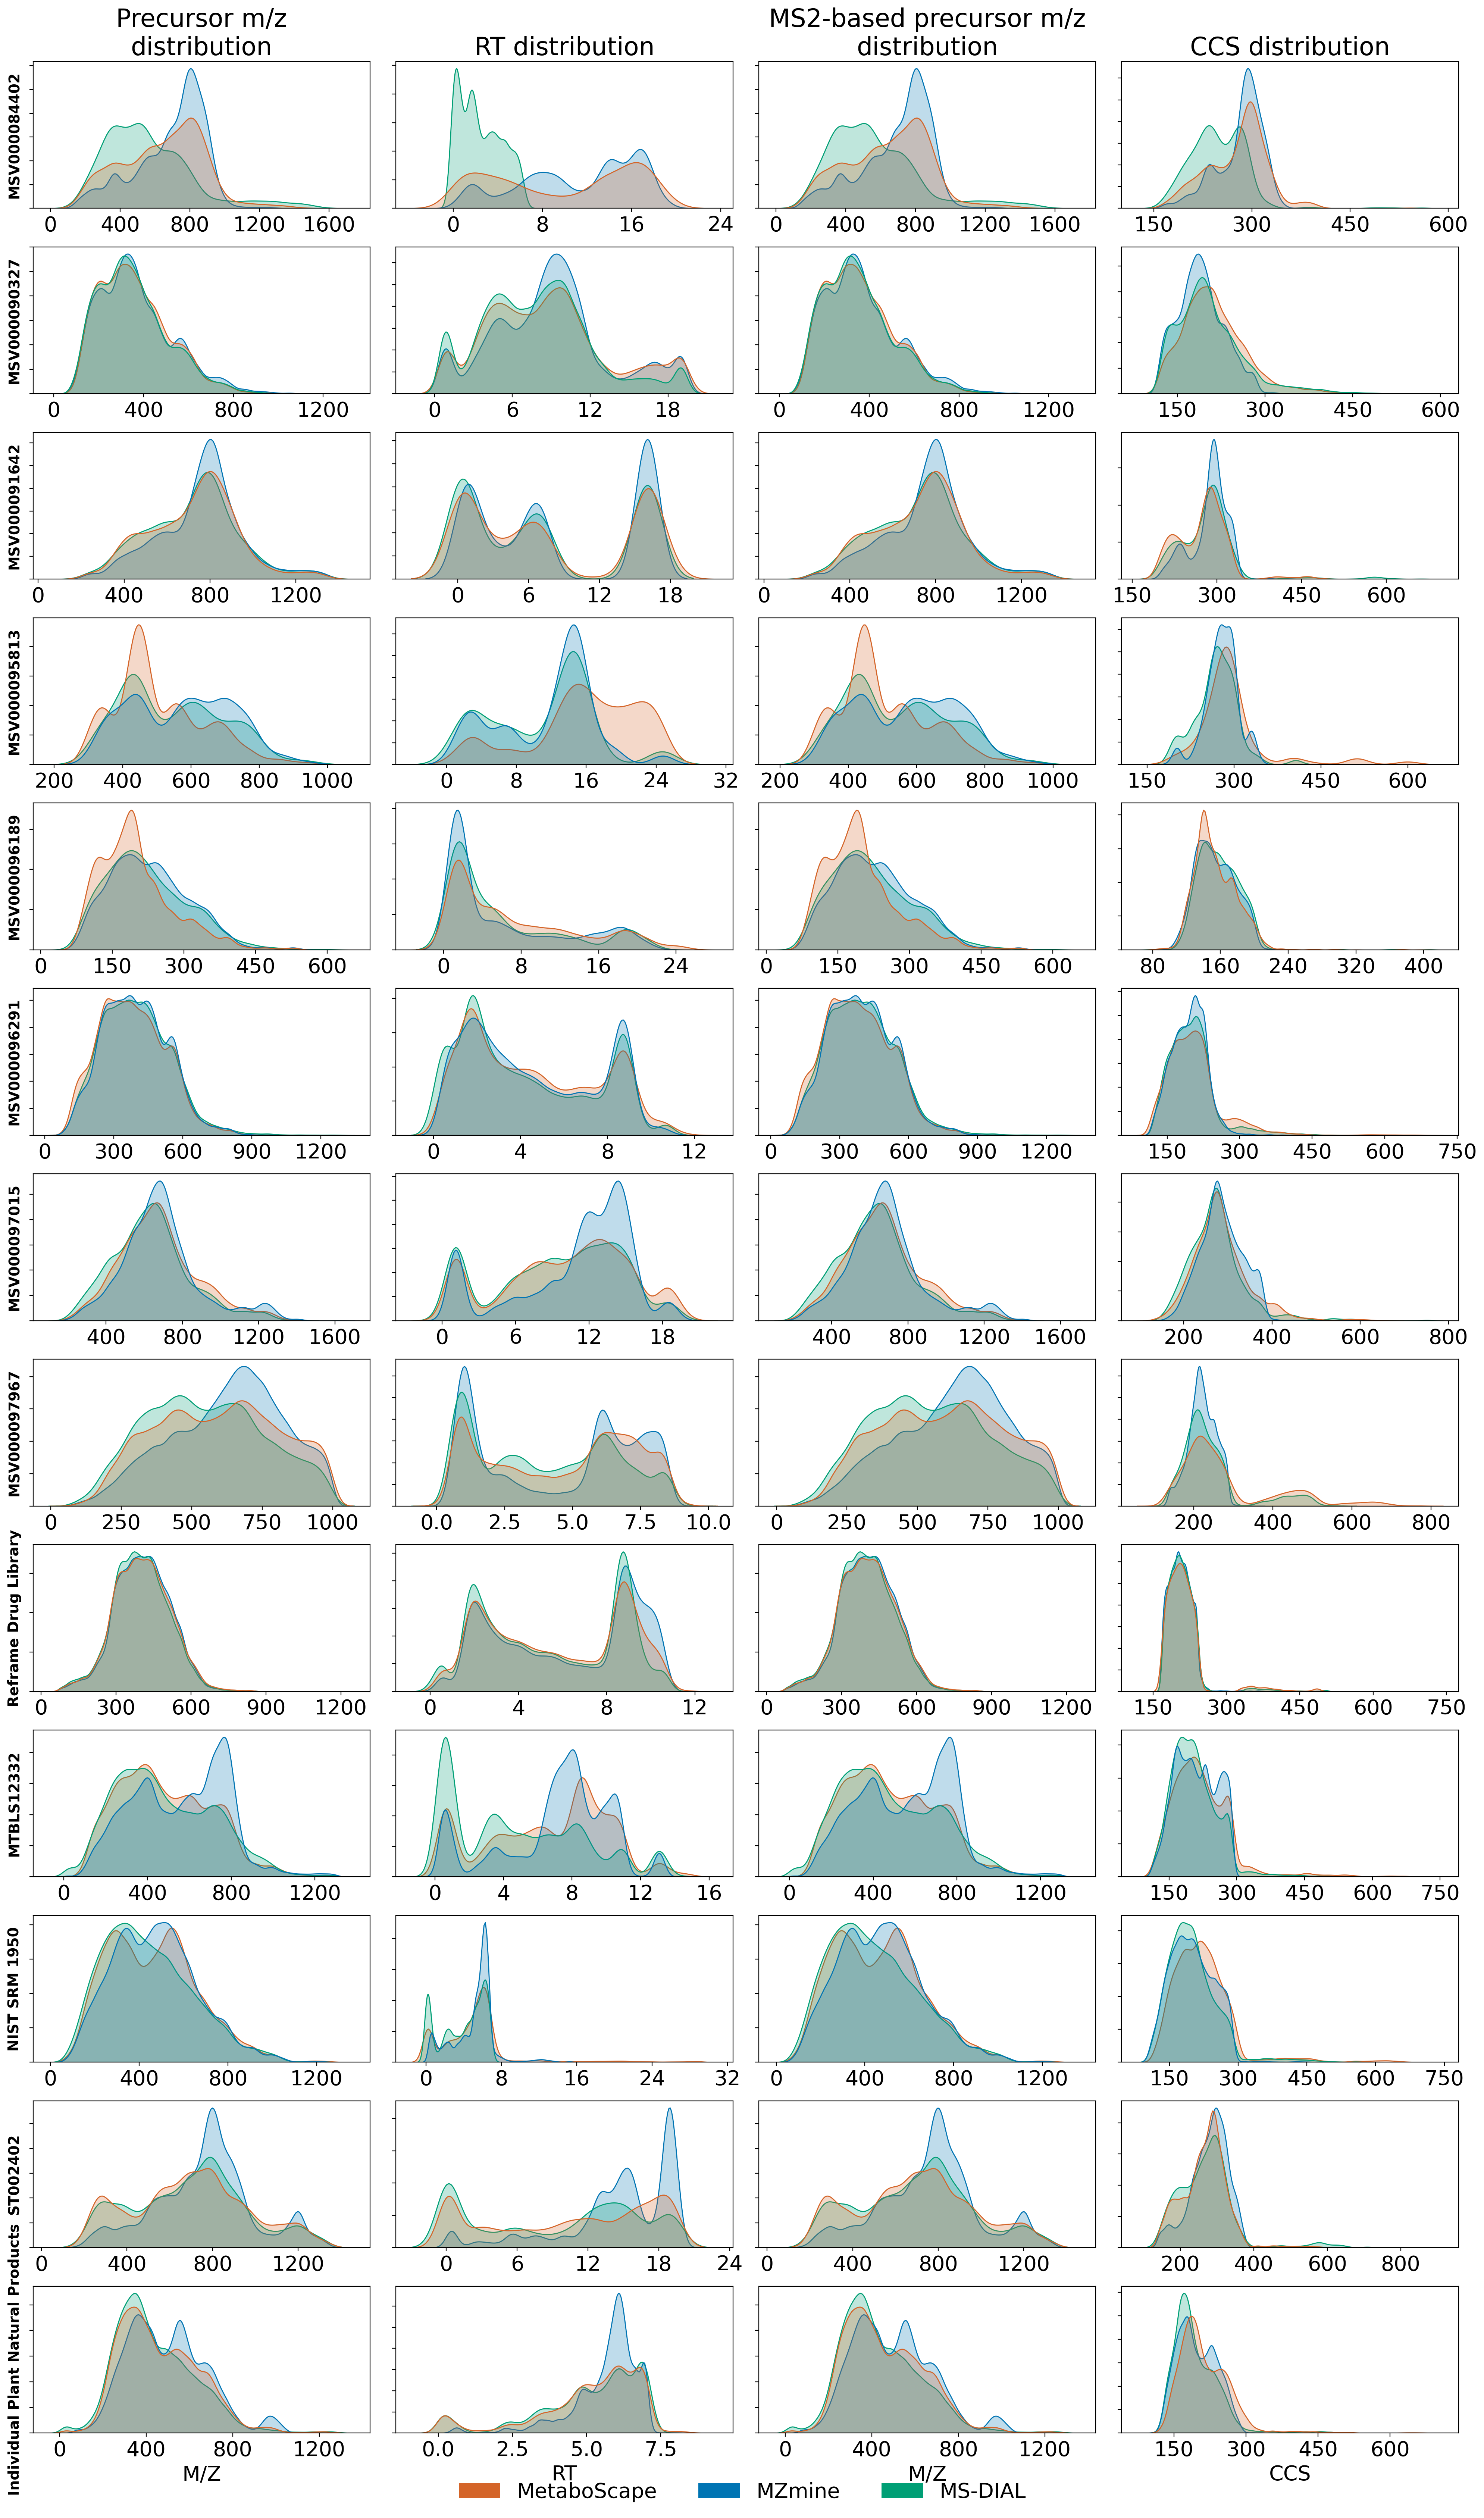

In [8]:
datasets = sorted(all_tables["dataset"].unique())
n_datasets = len(datasets)

columns = ["M/Z", "RT", "M/Z", "CCS"]
col_titles = [
    "Precursor m/z\ndistribution",
    "RT distribution",
    "MS2-based precursor m/z\ndistribution",
    "CCS distribution",
]

fig, axes = plt.subplots(
    nrows=n_datasets,
    ncols=4,
    figsize=(20, 2.5 * n_datasets + 1),
    dpi=200,
)

if n_datasets == 1:
    axes = [axes]

for row_idx, dataset in enumerate(datasets):
    group_df = all_tables[all_tables["dataset"] == dataset]
    ms2_based_df = group_df[group_df["MS/MS_ASSIGNED"]]

    for col_idx in range(4):
        ax = axes[row_idx][col_idx]
        plot_data = ms2_based_df if col_idx == 3 else group_df
        x_col = columns[col_idx]

        sns.kdeplot(
            data=plot_data,
            x=x_col,
            hue="tool",
            palette=TOOL_COLORS,
            fill=True,
            common_norm=False,
            ax=ax,
            legend=False,
        )

        # Titles only on first row
        if row_idx == 0:
            ax.set_title(col_titles[col_idx], fontsize=24)
        else:
            ax.set_title("")

        # X labels only on last row
        if row_idx == n_datasets - 1:
            ax.set_xlabel(x_col, fontsize=20)
            ax.tick_params(axis="x", labelsize=20)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelsize=20)

        # Dataset label on first column
        if col_idx == 0:
            label = DATASET_DESCRIPTORS.get(dataset, dataset)
            ax.set_ylabel(label, fontsize=14, fontweight="bold")
        else:
            ax.set_ylabel("")

        # Remove y tick labels
        ax.set_yticklabels([])

        # Max 6 x ticks
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

# Build legend handles manually from TOOL_NAMES / TOOL_COLORS
legend_handles = [
    Patch(facecolor=TOOL_COLORS[key], label=TOOL_NAMES[key]) for key in TOOL_NAMES
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(legend_handles),
    fontsize=20,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
)

plt.subplots_adjust(bottom=0.06)
plt.tight_layout()
plt.savefig("../figures/supplementary_figure_7.png", dpi=400, bbox_inches="tight")
plt.show()